In [1]:
from google.colab import drive
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Mount Google Drive (It will prompt you to click "Allow")
drive.mount('/content/drive')

# 2. Load the baseline cleaned data
# UPDATE THIS PATH if your file is named something different
file_path = '/content/drive/MyDrive/COMP331/AAPL_Cleaned_Sentiment.csv'
print(f"Loading data from {file_path}...")
df = pd.read_csv(file_path)

# 3. Isolate the Neutral/None data that we want to cluster
unlabeled_df = df[df['sentiment_clean'] == 'Neutral/None'].copy()
print(f"Found {len(unlabeled_df)} rows of Neutral/None data to cluster.")

# 4. Convert the text into numerical features for K-Means (TF-IDF)
print("Vectorizing the text (this takes a moment)...")
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_clustering = vectorizer.fit_transform(unlabeled_df['body'].fillna(''))

print("Setup Complete! The data is ready for the Elbow Method.")

Mounted at /content/drive
Loading data from /content/drive/MyDrive/COMP331/AAPL_Cleaned_Sentiment.csv...


/tmp/ipykernel_9781/907345357.py:12: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Found 383369 rows of Neutral/None data to cluster.
Vectorizing the text (this takes a moment)...
Setup Complete! The data is ready for the Elbow Method.


Calculating optimal K... this will take a moment.
Finished testing K=2
Finished testing K=3
Finished testing K=4
Finished testing K=5
Finished testing K=6
Finished testing K=7
Finished testing K=8
Finished testing K=9
Finished testing K=10


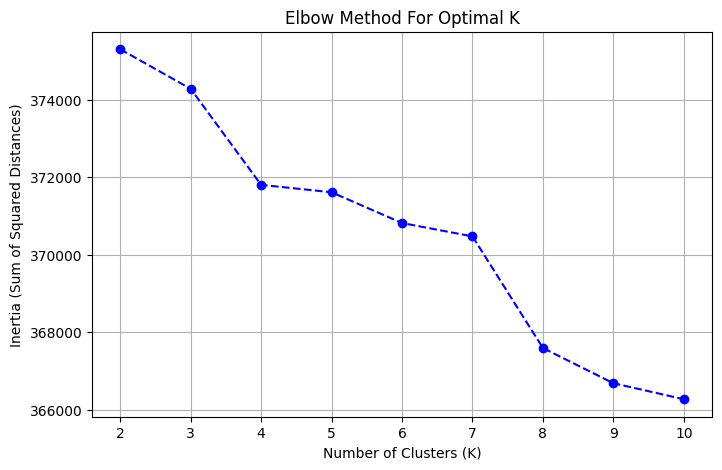

In [2]:
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
import warnings
warnings.filterwarnings("ignore") # Hides some annoying KMeans memory warnings

print("Calculating optimal K... this will take a moment.")

# Calculate inertia (error) for k values from 2 to 10
inertia = []
k_values = range(2, 11)

for k in k_values:
    # MiniBatchKMeans is much faster for large datasets than standard KMeans
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=2048)
    kmeans.fit(X_clustering)
    inertia.append(kmeans.inertia_)
    print(f"Finished testing K={k}")

# Plot the Elbow Graph
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o', linestyle='--', color='b')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.xticks(k_values)
plt.grid(True)
plt.show()

Compressing 5000 word dimensions into 2D for graphing... (This takes a minute)
Running final K-Means with K=2...


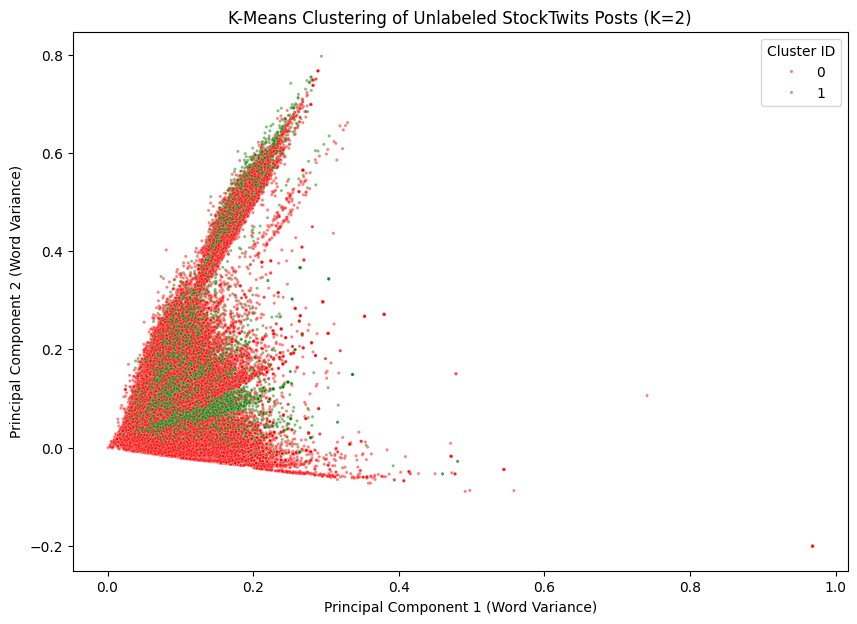


--- Cluster Distribution ---
cluster_id
0    316573
1     66796
Name: count, dtype: int64

Let's peek at the text in Cluster 0:
['$AMZN &amp; i’m out. ez call. expecting an aapl move'
 '$AMZN if they don’t hit this ER hard, look out below.  MSFT and AAPL getting punished for clobbering earnings.  If this misses ...'
 'Wow that sell off on $SPY now I don’t know about swing trading $AAPL $MSFT well at least I got my $AMZN swing trade profit https://youtu.be/lNBBkG4SnWU']

Let's peek at the text in Cluster 1:
['$AMZN Is this going to be AAPL ER move in two hours, where earnings and margins mean nothing?  😂😂😂.  Go buy some $GME people if you want to make money.  Market does not care what the company is making.  It is all FOMO trading.   Just like the government, fear of missing not spending the trillions that they don’t have fast enough.  SMH.'
 '$AMZN A split would make AMZN stock far more accessible.  It will run like crazy if it is split.   Do your homework.   Look at AAPL, TSLA etc on

In [3]:
from sklearn.decomposition import TruncatedSVD
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

print("Compressing 5000 word dimensions into 2D for graphing... (This takes a minute)")

# 1. Compress the data for the scatter plot
svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_clustering)

print("Running final K-Means with K=2...")
# 2. Run KMeans with K=2 to force two groups (Bullish/Bearish)
final_kmeans = MiniBatchKMeans(n_clusters=2, random_state=42, batch_size=2048)
cluster_labels = final_kmeans.fit_predict(X_clustering)

# 3. Create a DataFrame just for graphing
plot_df = pd.DataFrame({'X': X_2d[:, 0], 'Y': X_2d[:, 1], 'Cluster': cluster_labels})

# 4. Plot the Scatter Graph
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=plot_df, x='X', y='Y', hue='Cluster',
    palette=['red', 'green'], s=5, alpha=0.5
)
plt.title('K-Means Clustering of Unlabeled StockTwits Posts (K=2)')
plt.xlabel('Principal Component 1 (Word Variance)')
plt.ylabel('Principal Component 2 (Word Variance)')
plt.legend(title='Cluster ID')
plt.show()

# ---------------------------------------------------------
# STEP 3: Assigning the Predictions Back to the Data
# ---------------------------------------------------------

# Create a copy of your unlabeled data
unlabeled_clustered_df = unlabeled_df.copy()

# Add the 0 or 1 cluster labels
unlabeled_clustered_df['cluster_id'] = cluster_labels

print("\n--- Cluster Distribution ---")
print(unlabeled_clustered_df['cluster_id'].value_counts())

print("\nLet's peek at the text in Cluster 0:")
print(unlabeled_clustered_df[unlabeled_clustered_df['cluster_id'] == 0]['body'].head(3).values)

print("\nLet's peek at the text in Cluster 1:")
print(unlabeled_clustered_df[unlabeled_clustered_df['cluster_id'] == 1]['body'].head(3).values)

In [7]:
# ==========================================
# 1. Re-Initialize and Combine the Data safely
# ==========================================
# Start fresh from the original 'df' and 'unlabeled_df' to avoid KeyErrors
labeled_df = df[df['sentiment_clean'].isin(['Bullish', 'Bearish'])].copy()
unlabeled_clustered_df = unlabeled_df.copy()

# Re-apply the raw 0 and 1 cluster labels we generated earlier
unlabeled_clustered_df['cluster_id'] = cluster_labels

# Map the clusters to our chosen sentiments
cluster_mapping = {0: 'Bearish', 1: 'Bullish'}
unlabeled_clustered_df['sentiment_clean'] = unlabeled_clustered_df['cluster_id'].map(cluster_mapping)

# Drop the temporary cluster_id column safely
unlabeled_clustered_df = unlabeled_clustered_df.drop(columns=['cluster_id'])

# Combine the K-Means predicted data with your originally labeled data
final_kmeans_df = pd.concat([labeled_df, unlabeled_clustered_df])

print(f"Final K-Means completed dataset: {len(final_kmeans_df)} rows")

# Save this specific K-Means version to your Drive
kmeans_path = '/content/drive/MyDrive/apple_kmeans_labeled.csv'
final_kmeans_df.to_csv(kmeans_path, index=False)
print(f"Successfully saved K-Means dataset to: {kmeans_path}\n")


Final K-Means completed dataset: 771914 rows
Successfully saved K-Means dataset to: /content/drive/MyDrive/apple_kmeans_labeled.csv

--- Calculating K-Means Daily Predictive Accuracy ---


KeyError: "Column(s) ['Price_Change'] do not exist"

In [9]:
import yfinance as yf
import pandas as pd

print("Fetching Apple stock prices using flat format...")

# 1. Use yf.Ticker() instead of download() to guarantee a flat DataFrame
aapl = yf.Ticker("AAPL")
# Pulling a slightly wider range to ensure 8/12/2020 - 4/29/2021 is fully covered
apple_stock = aapl.history(start='2020-08-01', end='2021-05-05')
apple_stock = apple_stock.reset_index()

# 2. Standardize dates to match your M/DD/YYYY format perfectly
# yfinance adds timezones, so we strip them out before converting to .date
apple_stock['Date'] = pd.to_datetime(apple_stock['Date']).dt.tz_localize(None).dt.date
final_kmeans_df['date'] = pd.to_datetime(final_kmeans_df['date']).dt.date

# 3. Calculate the Next Day Price Change
apple_stock['Next_Close'] = apple_stock['Close'].shift(-1)
apple_stock['Price_Change'] = apple_stock['Next_Close'] - apple_stock['Close']

# 4. Merge the Price_Change column into your K-Means dataset
final_kmeans_df = pd.merge(
    final_kmeans_df,
    apple_stock[['Date', 'Price_Change']],
    left_on='date',
    right_on='Date',
    how='left'
)

# Fix any weekend gaps by backward filling the stock prices
final_kmeans_df['Price_Change'] = final_kmeans_df['Price_Change'].bfill()

print("Prices successfully merged! Calculating Accuracy...\n")

# ==========================================
# Evaluate K-Means Performance
# ==========================================
# Group the data by date to find the majority sentiment for each day
daily_summary_kmeans = final_kmeans_df.groupby('date').agg(
    majority_sentiment=('sentiment_clean', lambda x: x.mode()[0] if not x.mode().empty else None),
    price_change=('Price_Change', 'first')
).dropna()

# Define the evaluation logic
def check_accuracy(row):
    if row['majority_sentiment'] == 'Bullish' and row['price_change'] > 0:
        return 1
    elif row['majority_sentiment'] == 'Bearish' and row['price_change'] < 0:
        return 1
    else:
        return 0

# Apply the logic
daily_summary_kmeans['correct_prediction'] = daily_summary_kmeans.apply(check_accuracy, axis=1)

# Calculate final metrics
total_days_kmeans = len(daily_summary_kmeans)
correct_days_kmeans = daily_summary_kmeans['correct_prediction'].sum()
accuracy_kmeans = (correct_days_kmeans / total_days_kmeans) * 100

print(f"Total Trading Days Analyzed: {total_days_kmeans}")
print(f"Correctly Predicted Days: {correct_days_kmeans}")
print(f"K-Means Predictive Accuracy: {accuracy_kmeans:.2f}%")

Fetching Apple stock prices using flat format...
Prices successfully merged! Calculating Accuracy...

Total Trading Days Analyzed: 2242
Correctly Predicted Days: 1088
K-Means Predictive Accuracy: 48.53%


In [10]:
# Check the final distribution of the K-Means dataset
print("--- Final K-Means Label Distribution ---")
print(final_kmeans_df['sentiment_clean'].value_counts())

# Calculate the percentages for your report
total_rows = len(final_kmeans_df)
bullish_count = len(final_kmeans_df[final_kmeans_df['sentiment_clean'] == 'Bullish'])
bearish_count = len(final_kmeans_df[final_kmeans_df['sentiment_clean'] == 'Bearish'])

print(f"\nBullish Percentage: {(bullish_count / total_rows) * 100:.1f}%")
print(f"Bearish Percentage: {(bearish_count / total_rows) * 100:.1f}%")

--- Final K-Means Label Distribution ---
sentiment_clean
Bearish    409537
Bullish    362377
Name: count, dtype: int64

Bullish Percentage: 46.9%
Bearish Percentage: 53.1%
